<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>


# High-Dimensional Headache: How Extra Features Confuse Subsurface Models

### Sultan K. Dwier
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences
________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The University of Texas at Austin  
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin  

### Executive Summary

<p style="text-align: justify; line-height: 2.0;">
    In subsurface workflows, we often work with many well logs and derived attributes, but only a subset truly controls the response of interest. This workflow uses synthetic reservoir-style data to investigate the curse of dimensionality by progressively adding irrelevant features and evaluating how a distance-based model (KNN) deteriorates as feature space expands. We analyze this behavior using geometric distance statistics and illustrate how dimensionality reduction through PCA can recover meaningful low-dimensional structure from noisy, high-dimensional data. The results show that feature selection or dimensionality reduction is essential for maintaining predictive performance in subsurface machine learning workflows.
</p>



### Import Packages

<p style="text-align: justify; line-height: 2.0;">
We start by importing the packages required for generating synthetic data, building and evaluating machine learning models, and visualizing geometric effects in high dimensions.


In [252]:
import numpy as np                                        # numerical arrays and random sampling
import pandas as pd                                       # tabular data handling
import matplotlib.pyplot as plt                           # plotting and visualization
from mpl_toolkits.mplot3d import Axes3D                   # 3D scatter plots for dimensionality demo

from sklearn.model_selection import train_test_split      # train / test data splitting
from sklearn.neighbors import KNeighborsRegressor         # distance-based regression model
from sklearn.preprocessing import StandardScaler          # feature standardization
from sklearn.decomposition import PCA                     # dimensionality reduction (PCA)
from sklearn.metrics import r2_score, mean_squared_error  # regression performance metrics

from ipywidgets import interact, IntSlider                # interactive dashboard widgets

from scipy.special import gamma                           # hypersphere volume calculation
from scipy.spatial.distance import cdist                  # pairwise distance calculations

np.random.seed(2025)                                      # reproducible random number generation

plt.rcParams["figure.figsize"] = (5, 4)                   # default figure size
plt.rcParams["axes.grid"] = False                         # disable gridlines for better presentation

# Structure of this workflow inspired by examples from
# Pyrcz, "Subsurface Machine Learning" course resources (2025).

<p style="text-align: justify; line-height: 2.0;">
The packages above cover numerical work (<code>numpy</code>), tabular data handling (<code>pandas</code>), and visualization (<code>matplotlib</code>). <code>scikit-learn</code> provides the tools for building and evaluating the <code>KNeighborsRegressor</code> model and performing dimensionality reduction with <code>PCA</code>, while <code>scipy</code> supports pairwise distance calculations and hypersphere volume formulas used to illustrate geometric effects in high-dimensional spaces.
</p>


### Functions
<p style="text-align: justify; line-height: 2.0;">
The following functions are used throughout the workflow. They (1) generate synthetic subsurface data, (2) create geometric visualizations of high-dimensional space, (3) run the KNN performance experiment as dimensionality increases, and (4) apply PCA to high-dimensional synthetic logs. Defining these building blocks up front keeps the later workflow cells compact and easier to follow.

> The geometric distance and volume demonstrations are conceptually inspired by material from Prof. Michael Pyrcz’s Subsurface Machine Learning course resources.



In [266]:
def make_subsurface_data(n_samples=1000, n_noise=0, seed=2025):
    """
    Generate synthetic subsurface-style data.

    - 3 informative features:
        phi     : porosity (fraction)
        k_md    : permeability (mD)
        So      : oil saturation (fraction)
    - n_noise additional features:
        purely random, contain no signal about the target

    Target y is a simplified "productivity index" depending
    only on phi, k_md, and So.
    """
    rng = np.random.RandomState(seed)

    # real-ish features
    phi = rng.uniform(0.06, 0.32, size=(n_samples, 1))              # porosity
    k_md = rng.lognormal(mean=2.3, sigma=0.5, size=(n_samples, 1))  # permeability mD
    so = rng.uniform(0.35, 0.9, size=(n_samples, 1))                # oil saturation

    X_signal = np.hstack([phi, k_md, so])

    # target: something like oil rate / productivity index
    y = (
        0.55 * phi[:, 0]
        + 0.0025 * k_md[:, 0]
        + 0.45 * so[:, 0]
        + 0.12 * phi[:, 0] * so[:, 0]
        + rng.normal(0, 0.03, size=n_samples)
    )

    # extra logs that are useless
    if n_noise > 0:
        X_noise = rng.normal(loc=0.0, scale=1.0, size=(n_samples, n_noise))
        X = np.hstack([X_signal, X_noise])
    else:
        X = X_signal

    feature_names = ["phi", "perm_md", "So"] + [f"junk_{i+1}" for i in range(n_noise)]
    return X, y, feature_names

# 1D plot
def plot_1d_view():
    rng = np.random.RandomState(7)
    n = 80

    fig = plt.figure(figsize=(12, 4))
    x = np.arange(n)
    v = rng.uniform(0, 1, size=n)
    plt.plot(x, v, "o-", color="tab:red", markersize=4)
    fig.text(0.5, -0.04, "Figure 1. One-dimensional data plotted as a line with scattered values.", 
         ha="center", va="top")
    plt.title("1D view")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.show()

# 2D plot
def plot_2d_view():
    rng = np.random.RandomState(7)
    n = 80

    fig = plt.figure(figsize=(12, 5))
    x = rng.uniform(0, 1, size=n)
    y = rng.uniform(0, 1, size=n)
    plt.scatter(x, y, c="tab:red")
    fig.text(0.5, -0.04, "Figure 2. Two-dimensional scatter plot.", 
         ha="center", va="top")
    plt.title("2D scatter")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# 3D plot
def plot_3d_view():
    rng = np.random.RandomState(7)
    n = 80

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    x = rng.uniform(0, 1, size=n)
    y = rng.uniform(0, 1, size=n)
    z = rng.uniform(0, 1, size=n)

    ax.scatter(x, y, z, c='tab:red', s=40, alpha=0.8)

    # title above axes
    ax.set_title("3D scatter", pad=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    fig.text(
        0.5, -0.04,                       # x, y in figure coordinates
        "Figure 3. Three-dimensional scatter plot.", 
        ha="center", va="top"
    )

    plt.tight_layout()
    plt.show()

# 4D plot
def plot_4d_view():
    rng = np.random.RandomState(7)
    n = 80

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")
    x = rng.uniform(0, 1, size=n)
    y = rng.uniform(0, 1, size=n)
    z = rng.uniform(0, 1, size=n)
    c = np.sin(3 * x + 2 * y + z)

    sc = ax.scatter(x, y, z, c=c, cmap="plasma", s=70, alpha=0.9)
    cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
    cb.set_label("4th feature")

    ax.set_title("3D + color for 4th feature", pad=20)
    fig.text(0.5, 0.1, "Figure 4. Three-dimensional scatter plot with color encoding a 4th feature.", 
         ha="center", va="top")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

# 5D plot
def plot_5d_view():
    rng = np.random.RandomState(7)
    n = 80

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")
    x = rng.uniform(0, 1, size=n)
    y = rng.uniform(0, 1, size=n)
    z = rng.uniform(0, 1, size=n)
    c = rng.uniform(0, 1, size=n)
    s = 60 + 500 * rng.uniform(0, 1, size=n)

    sc = ax.scatter(x, y, z, c=c, s=s, cmap="magma", alpha=0.85)
    cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1)
    cb.set_label("4th feature")

    ax.set_title("3D + color + size for 5th feature", pad=20)
    fig.text(0.5, 0.1, "Figure 5. Three-dimensional scatter plot with color and size representing 4th and 5th features.", 
         ha="center", va="top")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

def plot_sphere_cube_ratio(max_dim=20):
    """
    Plots the ratio of hypersphere volume to hypercube volume vs. dimension.
    Shows that most of the volume "escapes" the sphere in high dimensions.
    """
    dims = np.arange(1, max_dim + 1)
    ratios = []
    for d in dims:
        vol_cube = 2 ** d
        vol_sphere = (np.pi ** (d / 2)) / gamma(d / 2 + 1)
        ratios.append(vol_sphere / vol_cube)
    fig = plt.figure(figsize=(12, 5))
    fig.text(0.5, -0.02, "Figure 6. Ratio of hypersphere to hypercube volume vs. dimension.",
         ha="center", va="top")
    plt.plot(dims, ratios, marker="o", linestyle="--", color="tab:red")
    plt.xlabel("Dimension")
    plt.ylabel("Sphere volume / cube volume")
    plt.title("Hypersphere-to-Hypercube Volume Ratio")
    plt.grid(False)
    plt.yscale("log")
    plt.show()


def plot_distance_cv(max_dim=50, n_points=120):
    """
    Computes the coefficient of variation (CV) of pairwise distances for
    points uniformly sampled in [0, 1]^d as a function of dimension.
    """
    dims = np.arange(1, max_dim + 1)
    cvs = []
    for d in dims:
        pts = np.random.rand(n_points, d)
        dists = cdist(pts, pts, metric="euclidean")
        mask = ~np.eye(dists.shape[0], dtype=bool)
        d_flat = dists[mask]
        cv = np.std(d_flat) / np.mean(d_flat)
        cvs.append(cv)
    fig = plt.figure(figsize=(12, 5))
    fig.text(0.5, -0.02, "Figure 7. Coefficient of variation of pairwise distances vs. dimension.",
         ha="center", va="top")
    plt.plot(dims, cvs, marker="o", color="tab:red")
    plt.xlabel("Dimension")
    plt.ylabel("Coef. of variation of pairwise distances")
    plt.title("Coefficient of Variation of Pairwise Distances")
    plt.grid(False)
    plt.show()


def panel_distance_histograms():
    """
    Panel of histograms of pairwise distances for increasing dimensions.
    Shows how the distance distribution tightens as dimensionality increases.
    """
    N = 500
    dims = [1, 2, 4, 8, 16, 32, 48, 64]
    nrows = 2
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6), constrained_layout=True)
    axes = axes.flatten()
    for i, d in enumerate(dims):
        pts = np.random.rand(N, d)
        dist = cdist(pts, pts)
        mask = ~np.eye(N, dtype=bool)
        dist_flat = dist[mask]
        m = dist_flat.mean()
        s = dist_flat.std()
        cv = s / m

        axes[i].hist(dist_flat, bins=60, color="tab:red", edgecolor="k")
        axes[i].set_title(f"{d}D, CV={cv:.2f}", fontsize=9)
        axes[i].set_xlabel("Distance")
        axes[i].set_ylabel("Frequency")
    fig = plt.gcf()
    fig.text(0.5, -0.02, "Figure 8. Pairwise distance distributions across increasing dimensions.",
         ha="center", va="top")
    plt.suptitle("Distance Distribution Panels")
    plt.grid(False)
    plt.show()

def model_vs_dimension(max_noise=50, step=2):
    """
    For n_noise = 0, 2, ..., max_noise:
    - generate data with 3 signal + n_noise noise features
    - train and evaluate KNN
    - record R² and MSE on the test set
    """
    rows = []
    for n_noise in range(0, max_noise + 1, step):
        X, y, names = make_subsurface_data(
            n_samples=1200,
            n_noise=n_noise,
            seed=8
        )
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=11
        )

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        knn = KNeighborsRegressor(n_neighbors=5)
        knn.fit(X_train_sc, y_train)
        y_pred = knn.predict(X_test_sc)

        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        rows.append({
            "total_features": 3 + n_noise,
            "n_noise": n_noise,
            "r2": r2,
            "MSE": mse
        })

    df = pd.DataFrame(rows)
    return df

def PCA_CoD():
    """
    PCA variance capture vs dimensionality (2D to 20D).
    Uses subsurface-style features:
      - D = 2 : phi, perm_md
      - D = 3 : phi, perm_md, So
      - D > 3 : 3 signal features + (D - 3) noise features
    For each dimensionality D, computes the fraction of total variance
    captured by PC1 + PC2 and plots it as a function of D.
    """

    rng = np.random.RandomState(123)
    n_samples = 800

    # base subsurface-style data with 3 informative features
    base, _, _ = make_subsurface_data(n_samples=n_samples, n_noise=0, seed=123)

    dims = list(range(2, 21))       # 2D to 20D
    var_pc12_list = []

    for D in dims:
        if D <= 3:
            X_tmp = base[:, :D]     # use first D signal features
        else:
            n_noise = D - 3
            noise = rng.normal(0, 1, size=(n_samples, n_noise))
            X_tmp = np.hstack([base, noise])

        # standardize features before PCA
        scaler = StandardScaler()
        X_tmp_sc = scaler.fit_transform(X_tmp)

        pca = PCA()
        pca.fit(X_tmp_sc)

        var_ratio = pca.explained_variance_ratio_
        var_pc12 = 100.0 * (var_ratio[0] + var_ratio[1])   # percent variance
        var_pc12_list.append(var_pc12)

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(dims, var_pc12_list, marker="o",color="tab:red")
    ax.set_xlabel("Number of features")
    ax.set_ylabel("Variance captured by PC₁ & PC₂ (%)")
    ax.set_title("PCA variance captured vs. dimensionality")
    ax.grid(False)
    ax.set_ylim(0, 105)

    fig.subplots_adjust(bottom=0.25)

    fig.text(
        0.5,
        0.15,
        "Figure 10.Total variance captured by PC₁ and PC₂ versus dimensionality.",
        ha="center",
        va="top",
        fontsize=14,
    )

    plt.show()


<p style="text-align: justify; line-height: 2.0;">
The functions above implement all the building blocks for the workflow. <code>make_subsurface_data</code> generates synthetic reservoir-style features along with a simplified productivity target, forming the core dataset used throughout the analysis. The geometric demonstrations, i.e. <code>visualize_1d_to_5d</code>, <code>plot_sphere_cube_ratio</code>, <code>plot_distance_cv</code>, and <code>panel_distance_histograms</code>, illustrate how structure, volume, and distances behave as dimensionality increases. The main experiment is handled by <code>model_vs_dimension</code>, which evaluates KNN performance as more noise features are added. Finally, <code>PCA_CoD</code> shows how PCA can recover low-dimensional structure from a high-dimensional, noisy synthetic log dataset.
</p>


### Load Data

<p style="text-align: justify; line-height: 2.0;">
This workflow relies entirely on synthetic data generated within the notebook. Synthetic datasets are ideal for demonstrating machine learning concepts because the underlying relationships are known, the level of difficulty can be controlled, and the data remain fully reproducible without relying on external files. The features represent simplified subsurface properties, including porosity (<code>phi</code>), permeability in milliDarcy (<code>perm_md</code>), and oil saturation (<code>So</code>), along with optional noise features (<code>junk_i</code>) that act as irrelevant logs. The target variable is a simplified productivity-like response that depends only on the three informative features, allowing us to clearly observe how additional noise dimensions affect model performance as part of the curse of dimensionality demonstration.
</p>



In [257]:
# generate a small example dataset to inspect structure
X_example, y_example, feature_names_example = make_subsurface_data(
    n_samples=10,
    n_noise=4,
    seed=42
)

print("Feature names:", feature_names_example)
print("X_example shape:", X_example.shape)
print("y_example shape:", y_example.shape)


Feature names: ['phi', 'perm_md', 'So', 'junk_1', 'junk_2', 'junk_3', 'junk_4']
X_example shape: (10, 7)
y_example shape: (10,)


<p style="text-align: justify; line-height: 2.0;">
The example above confirms the expected feature layout: three meaningful reservoir properties followed by any number of noise attributes labeled <code>junk_i</code>. These additional dimensions are intentionally uninformative, which makes them useful for studying how distance-based models behave as the feature space grows. The structure also highlights how easily we can scale the dataset by adding more synthetic logs without altering the true relationship between inputs and target. In the main experiment we will work with 1,200 samples, three signal features, and up to 50 noise features to examine how model performance degrades as dimensionality increases.
</p>


### High-Dimensional Headache: Workflow Overview

<div style="text-align: justify; line-height: 2.0;">

This workflow is organized into five main steps that build a complete demonstration of the curse of dimensionality:

1. **Visualize data from 1D to 5D** to build intuition for how structure becomes harder to interpret as more dimensions are added.  
2. **Explore high-dimensional geometry** using hypersphere–hypercube volume ratios and distance statistics to understand why nearest neighbors become less meaningful.  
3. **Run a KNN regression experiment** to evaluate how model performance deteriorates as irrelevant noise features are added to the dataset.  
4. **Examine PCA variance capture across increasing dimensionality** to show how the explanatory power of the first two principal components decreases as high-dimensional noise overwhelms the signal.  
5. **Interactive demonstration of the curse of dimensionality with KNN** to visualize in real time how noise features and model complexity affect predictive performance in a subsurface-style setting.

</div>


### 1(a). Visualization of Data in 1D, 2D, and 3D
<p style="text-align: justify; line-height: 2.0;">
We begin with 1D, 2D, and 3D visualizations to build intuition for how data behave as dimensionality increases. These plots remain interpretable up to 3D, but even at this stage the structure becomes harder for the human eye to follow.
</p>




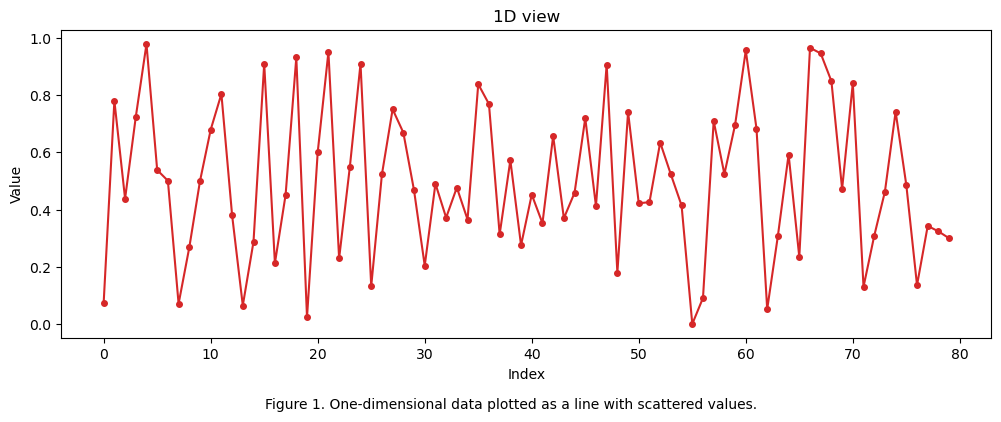

In [241]:
plot_1d_view()

<p style="text-align: justify; line-height: 2.0;">
Figure 1 shows a simple structure that is easy to interpret and serves as a baseline before increasing the dimensionality.
</p>


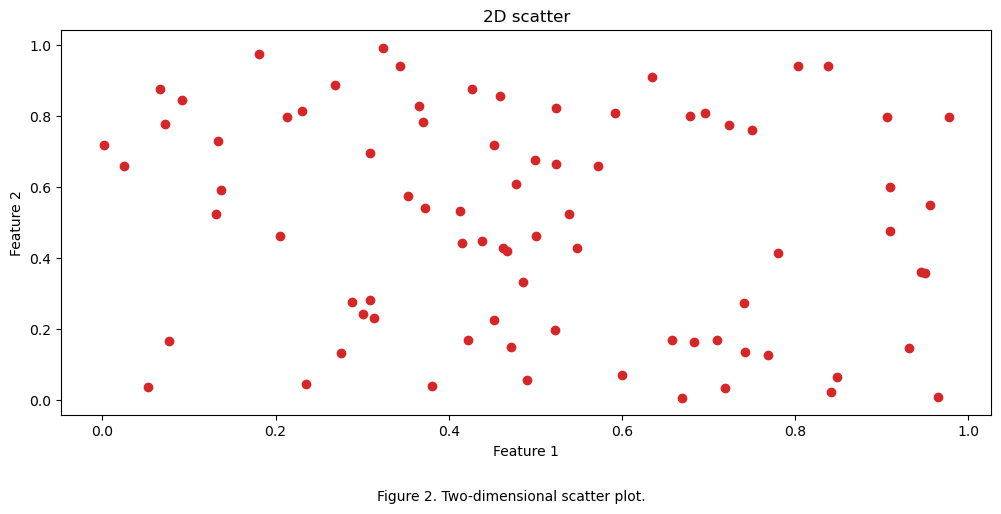

In [242]:
plot_2d_view()

<p style="text-align: justify; line-height: 2.0;">

    
It can be seen from Figure 2 that patterns remain intuitive and interpretable in 2D.
</p>


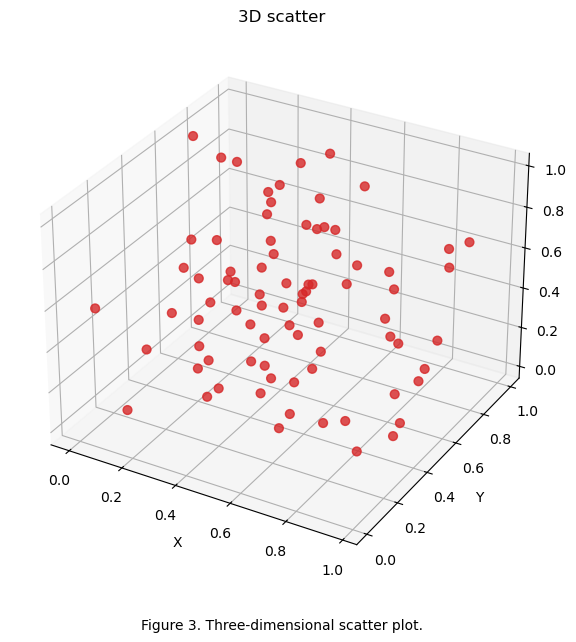

In [243]:
plot_3d_view()

<p style="text-align:justify; line-height: 2.0;">
Figure 3 shows that, while richer than 2D, depth perception and occlusion already make visual interpretation more challenging.
</p>


### 1(b). Visualization of Data in 4D and 5D
<p style="text-align: justify; line-height: 2.0;"> We extend the visualizations to 4D and 5D by encoding extra features using color and marker size on top of a 3D plot, respectively. These representations quickly become difficult to interpret, even though the underlying data are simple. This highlights how adding only a few dimensions can make structure much harder to recognize, motivating the need for dimensionality reduction in high-dimensional workflows. </p>

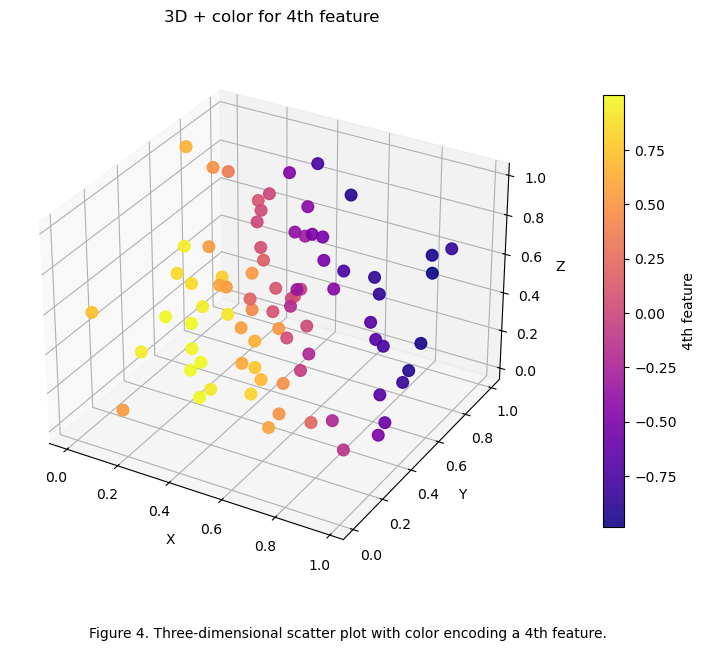

In [258]:
plot_4d_view()

<p style="text-align: justify; line-height: 2.0;">
Figure 4 visualizes four dimensions by plotting three spatial coordinates (X, Y, and Z) while encoding the fourth dimension as a continuous color scale. Although the underlying data are still simple, the need to represent the extra feature indirectly through color already makes the structure harder to interpret, illustrating the early stages of dimensionality-related complexity. </p>

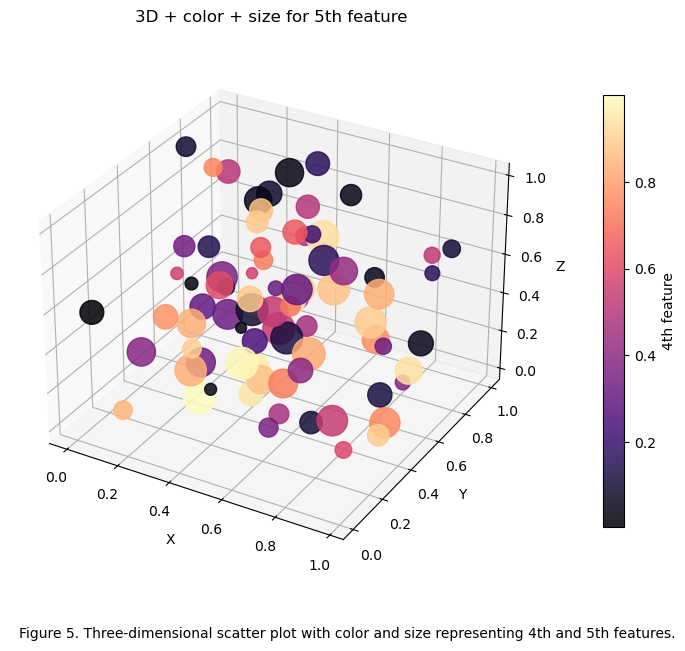

In [245]:
plot_5d_view()

<p style="text-align: justify; line-height: 2.0;">
Figure 5 extends the visualization to five dimensions by plotting X, Y, and Z in 3D space, while encoding the fourth dimension as color and the fifth as marker size. With two attributes now mapped indirectly through visual cues, the plot becomes noticeably harder to interpret, emphasizing how quickly complexity escalates as dimensionality increases. </p>

### 2. Geometry of High-Dimensional Spaces
<p style="text-align: justify; line-height: 2.0;">
This section explores how geometric intuition breaks down as dimensionality increases. We examine how the volume of a hypersphere shrinks relative to its enclosing hypercube, how pairwise distances become increasingly similar, and how the full distribution of distances tightens as the feature space expands. These effects are fundamental drivers of the curse of dimensionality because distance-based algorithms, such as KNN, rely on meaningful contrasts between near and far points. When high-dimensional geometry compresses those contrasts, model performance inevitably degrades. </p>

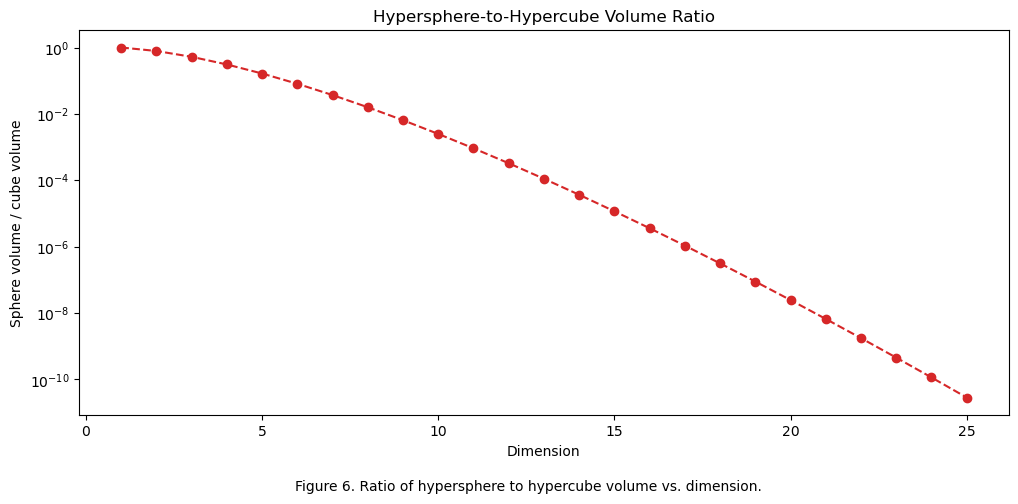

In [268]:
# ratio of hypersphere to hypercube volume vs dimension
plot_sphere_cube_ratio(max_dim=25)

<p style="text-align: justify; line-height: 2.0;"> 
    Figure 6 shows how quickly the volume of a unit hypersphere collapses relative to its enclosing hypercube as dimension increases. Although both shapes share the same radius of 1, the hypersphere occupies a rapidly decreasing fraction of the available volume. This demonstrates how “most of the space” moves outward toward the corners of the hypercube, contributing to sparse sampling and weakening distance-based intuition. </p>

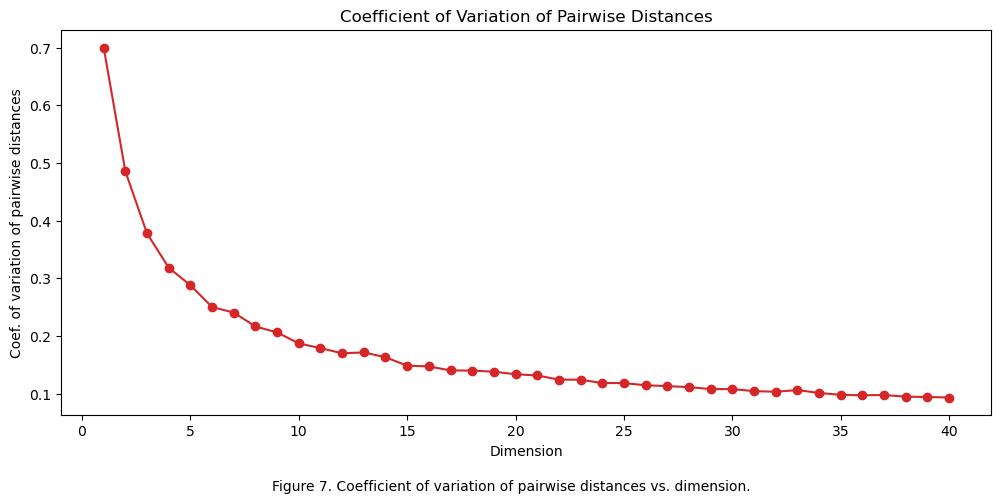

In [261]:
# coefficient of variation of pairwise distances vs dimension
plot_distance_cv(max_dim=40, n_points=100)

<p style="text-align: justify; line-height: 2.0;"> 
    Figure 7 illustrates how pairwise distances between random points become more similar as dimensionality increases. The coefficient of variation steadily decreases, meaning that the gap between the nearest and farthest neighbors shrinks. When distances lose contrast in this way, models like KNN struggle to distinguish meaningful neighbors from irrelevant ones. </p>

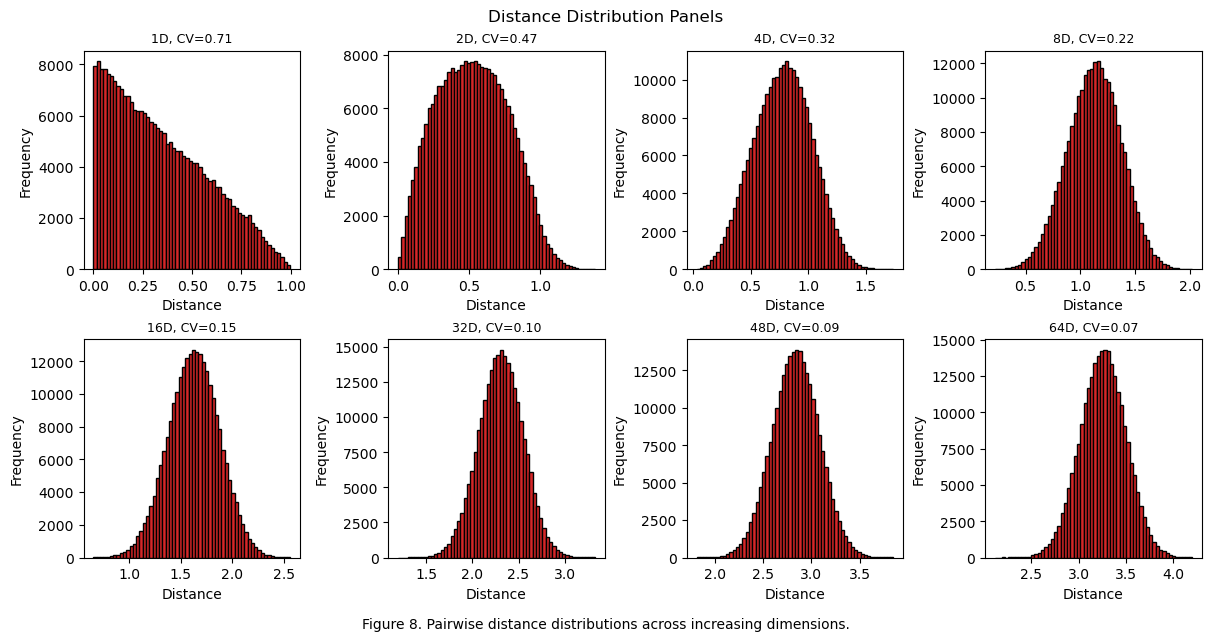

In [248]:
# panel of distance histograms for selected dimensions
panel_distance_histograms()

<p style="text-align: justify; line-height: 2.0;"> Figure 8 shows full distance distributions for several dimensions. As dimension grows, each histogram becomes sharply concentrated around a single value, indicating that all distances converge to approximately the same magnitude. This reinforces the idea that high-dimensional spaces flatten meaningful geometric structure, making neighborhood-based learning increasingly unreliable. </p>

### 3. Quantifying the Curse of Dimensionality Through KNN Regression
<p style="text-align: justify; line-height: 2.0;"> 
We now translate the geometric intuition from the previous section into a subsurface-style machine learning setting. K-Nearest Neighbors (KNN) is a simple distance-based regression method that predicts a value by averaging the target values of the closest points in feature space. Because closeness is measured using the Euclidean distance \[ d(\mathbf{x}_i, \mathbf{x}_j)=\sqrt{\sum_{k=1}^{D}(x_{ik}-x_{jk})^2}, \] the method is highly sensitive to dimensionality. The target variable in this experiment depends solely on the three meaningful reservoir properties: porosity, permeability, and oil saturation. By keeping the sample size fixed and incrementally adding noise features that contain no signal, we observe how the inflation of feature space weakens the ability of KNN to identify meaningful neighbors. This demonstrates how the curse of dimensionality degrades model performance even when the underlying physical relationship remains unchanged.
</p>

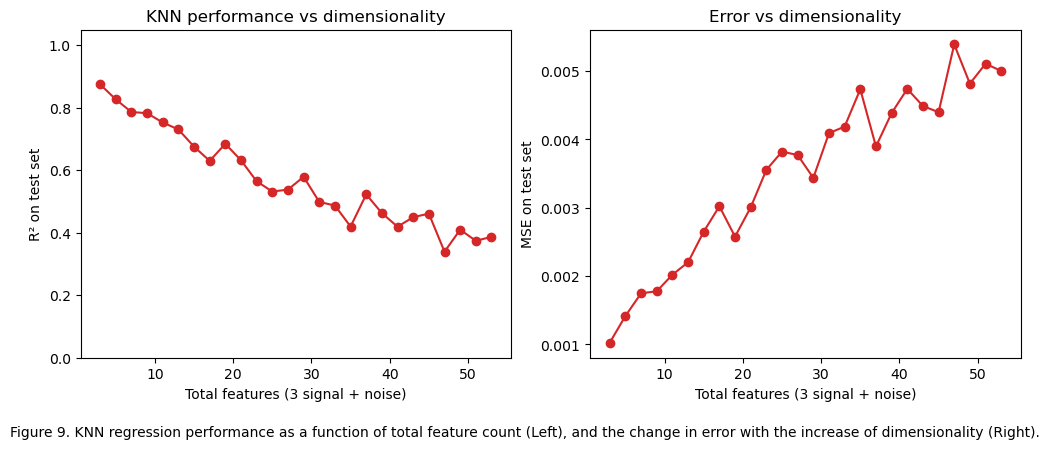

,Case,total_features,n_noise,R²,mse
0,Lowest Dimensionality (3 features),3.000000,0.000000,0.874476,0.001023
1,Highest Dimensionality (53 features),53.000000,50.000000,0.386358,0.005001


In [270]:
# run KNN experiment for increasing dimensionality
df_perf = model_vs_dimension(max_noise=50, step=2)

# combined plot: R² and MSE vs total features
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# R² subplot
axes[0].plot(df_perf["total_features"], df_perf["r2"], marker="o",color="tab:red")
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Total features (3 signal + noise)")
axes[0].set_ylabel("R² on test set")
axes[0].set_title("KNN performance vs dimensionality")
axes[0].grid(False)

# MSE subplot
axes[1].plot(df_perf["total_features"], df_perf["MSE"], marker="o", color="tab:red")
axes[1].set_xlabel("Total features (3 signal + noise)")
axes[1].set_ylabel("MSE on test set")
axes[1].set_title("Error vs dimensionality")
axes[1].grid(False)

fig = plt.gcf()
fig.text(0.5, -0.05,
         "Figure 9. KNN regression performance as a function of total feature count (Left), and the change in error with the increase of dimensionality (Right).",
         ha="center", va="top", fontsize=10)
plt.show()
# summary table
best_row = df_perf.iloc[0]
worst_row = df_perf.iloc[-1]

summary_df = summary_df.rename(columns={"R²": "R\u00b2"})

styled_summary = (
    summary_df.style
    .set_caption("Table 1. Summary of KNN performance at lowest and highest dimensionality.")
    .set_table_styles([
        {"selector": "caption",
         "props": [("text-align", "center"),
                   ("font-size", "11pt"),
                   ("padding-bottom", "8px")]},
        {"selector": "th",
         "props": [("text-align", "center")]},
    ])
    .set_properties(**{"text-align": "center"})
)

# display the table centered on the page
from IPython.display import HTML
HTML(f"<div style='display:flex; justify-content:center;'>{styled_summary.to_html()}</div>")

<p style="text-align: justify; line-height: 2.0;"> 
    Figure 9 and Table 1 show a clear and monotonic degradation in model quality as dimensions increase. With only the three informative features, the KNN model achieves strong predictive performance, but each additional noise feature lowers the contrast between distances in feature space, reducing the model's ability to identify meaningful neighbors. The decline in R² and the rise in MSE occur despite the fact that the target contains no added complexity, confirming that the drop in performance is driven solely by dimensionality. This behavior matches the geometric effects observed earlier and highlights why feature selection or dimensionality reduction is essential when working with many subsurface attributes. </p>


### 4. PCA as a Simple Dimensionality-Reduction Strategy

<p style="text-align: justify; line-height: 2.0;">
To close the workflow, we apply Principal Component Analysis (PCA) to our dataset with three informative features and sixty noise features. PCA is a linear dimensionality-reduction method that rotates the feature space to a new set of orthogonal axes along which the variance is maximized. We first standardize the data matrix \(\mathbf{X} \in \mathbb{R}^{n \times D}\) and compute its sample covariance matrix:
</p>

$$
\mathbf{S} = \frac{1}{n-1}\,\mathbf{X}^\top \mathbf{X}.
$$

<p style="text-align: justify; line-height: 2.0;">
PCA then solves the eigenvalue problem \(\mathbf{S}\mathbf{w}_j = \lambda_j \mathbf{w}_j\), where \(\mathbf{w}_j\) is the \(j\)-th principal direction and \(\lambda_j\) is its associated variance. The principal component scores are \(\mathbf{z}_j = \mathbf{X}\mathbf{w}_j\), and the fraction of total variance explained by component \(j\) is \(\lambda_j / \sum_k \lambda_k\). In this experiment, we use PCA to check whether a small number of principal components can recover structure related to porosity, even though the original feature space is dominated by noisy, uninformative logs.
</p>



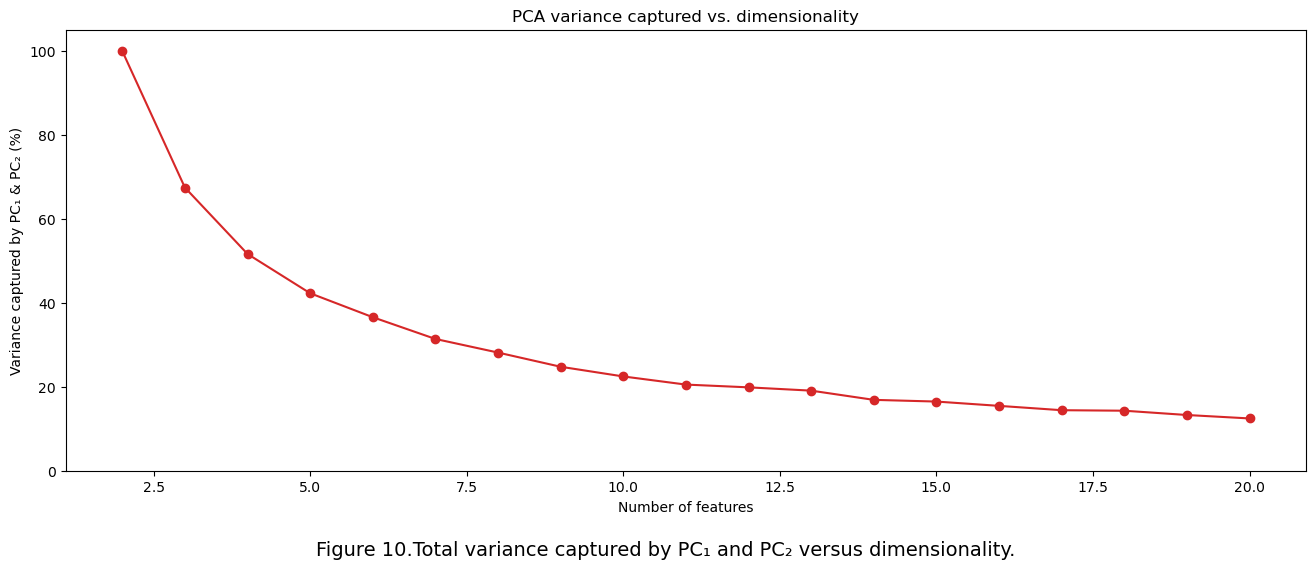

In [250]:
PCA_CoD()

<p style="text-align: justify; line-height: 2.0;">
Figure 10 illustrates how the fraction of total variance captured by the first two principal components declines steadily as dimensionality increases from 2D to 20D. When only a few meaningful subsurface features are present. PC₁ and PC₂ summarize nearly all of the structure in the dataset. As more noise dimensions are introduced, the variance becomes distributed across many directions, reducing the dominance of the leading components. This demonstrates a key aspect of the curse of dimensionality: high-dimensional data require more principal components to capture meaningful structure, and low-dimensional projections become increasingly less informative.
</p>


### 5. Interactive Demonstration of the Curse of Dimensionality with KNN

<p style="text-align: justify; line-height: 2.0;"> To make the curse of dimensionality more tangible, we conclude with an interactive KNN dashboard built on the synthetic subsurface dataset. The widget lets us vary the number of noise features, the number of neighbors, the sample size, and the random seed. For each configuration, a KNN regressor is trained to predict the productivity index, and two diagnostic plots are displayed: a cross-plot of predicted versus true values and a histogram of residuals. Because KNN relies entirely on distance comparisons in feature space, this interactive module provides an intuitive way to see how irrelevant dimensions distort distances and degrade prediction quality in a subsurface-style problem. </p>


In [273]:
def knn_subsurface_dashboard(n_noise=0, n_neighbors=5, n_samples=800, test_size=0.3, seed=42):
    """
    Interactive KNN dashboard on synthetic subsurface data.
    """
    # 1. generate data
    X, y, feature_names = make_subsurface_data(
        n_samples=n_samples,
        n_noise=n_noise,
        seed=seed
    )

    # 2. split and scale
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=11
    )

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    # 3. fit KNN
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_sc, y_train)
    y_pred = knn.predict(X_test_sc)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # 4. figure with cross-plot and residuals
    fig, axes = plt.subplots(1, 2, figsize=(19, 9))

    # cross-plot
    axes[0].scatter(y_test, y_pred, alpha=0.7,color="tab:red")
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)
    axes[0].set_xlabel("True productivity index")
    axes[0].set_ylabel("Predicted productivity index")
    axes[0].set_title("Prediction cross-plot")

    # residuals
    residuals = y_pred - y_test
    axes[1].hist(residuals, bins=30, edgecolor="k",color="tab:red")
    axes[1].set_xlabel("Residual (y_pred - y_true)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Residual distribution")

    # space + caption
    fig.subplots_adjust(bottom=0.25, wspace=0.15)
    fig.text(
        0.5,
        0.15,
        "Figure 11. Interactive KNN dashboard showing prediction cross-plot (Left) "
        "and residual distribution (Right).",
        ha="center",
        va="top",
        fontsize=14,
    )

    plt.show()
    return {
        "Total_Features": X.shape[1],
        "n_Noise": n_noise,
        "n_Neighbors": n_neighbors,
        "r2": r2,
        "MSE": mse
    }

from IPython.display import HTML, display

def update_knn_table(result_dict):
    df = pd.DataFrame([result_dict])

    # rename r2 to R²
    df = df.rename(columns={"r2": "R\u00b2"})

    # build styled table: hide index, center headers and cells
    styled = (
        df.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
        ])
        .set_properties(**{"text-align": "center"})
    )

    table_html = styled.to_html()

    html_full = f"""
    <div style="display:flex; justify-content:center; margin-top:10px;">
      <div>
        <p style="text-align:center; font-weight:bold; margin-bottom:4px;">
          Table 2. KNN performance summary for selected interactive settings.
        </p>
        {table_html}
      </div>
    </div>
    """
    display(HTML(html_full))

# interactive widget
def capture_and_display(n_noise, n_neighbors, n_samples, test_size, seed):
    result = knn_subsurface_dashboard(
        n_noise=n_noise,
        n_neighbors=n_neighbors,
        n_samples=n_samples,
        test_size=test_size,
        seed=seed
    )
    update_knn_table(result)

interact(
    capture_and_display,
    n_noise=IntSlider(min=0, max=50, step=2, value=0, description="Noise"),
    n_neighbors=IntSlider(min=1, max=25, step=2, value=5, description="K neighbors"),
    n_samples=IntSlider(min=300, max=1500, step=100, value=800, description="Samples"),
    test_size=(0.2, 0.4, 0.05),
    seed=IntSlider(min=1, max=999, step=10, value=42, description="Seed")
);

interactive(children=(IntSlider(value=0, description='Noise', max=50, step=2), IntSlider(value=5, description=…

<p style="text-align: justify; line-height: 2.0;"> 
    Exploring the widget reveals several consistent trends. With few or no noise features, the prediction cross-plot falls tightly along the 1:1 line and the residual histogram remains narrow, indicating strong KNN performance. As we increase the number of irrelevant features, the cross-plot becomes more scattered and the residual distribution widens, reflecting a drop in R² and a rise in MSE. This happens because distance calculations become dominated by noise, reducing the contrast between nearest and farthest neighbors. Adjusting the number of neighbors also illustrates the classic bias–variance tradeoff: a very small K fluctuates more, while a very large K oversmooths the underlying relationship. Together, the interactive controls make the curse of dimensionality visually and intuitively clear—despite the true physics remaining unchanged, the model struggles increasingly as uninformative dimensions are added. </p>


### Results

<p style="text-align: justify; line-height: 2.0;">
The synthetic subsurface dataset was designed so that the target variable depended only on porosity, permeability, and oil saturation, while all additional features represented pure noise. This controlled setup made it possible to isolate the effects of dimensionality from geological complexity. The geometric analyses confirmed the classic behavior of high-dimensional spaces: hypersphere–hypercube volume ratios collapsed rapidly with dimension, the distribution of pairwise distances tightened, and nearest neighbors became increasingly indistinguishable from farthest ones. These effects directly undermine distance-based learning methods.
</p>

<p style="text-align: justify; line-height: 2.0;">
The KNN regression experiment demonstrated this breakdown clearly. With only the three meaningful features, KNN achieved high predictive accuracy, but as noise dimensions were added, test-set R² dropped and MSE increased consistently despite the underlying physics remaining unchanged. This reflects the dilution of distance information in high-dimensional spaces, where irrelevant features dominate the distance metric and obscure true similarity. The interactive KNN dashboard reinforced these trends by showing, in real time, how model performance deteriorates as noise features accumulate or model complexity (K) is poorly tuned.
</p>

<p style="text-align: justify; line-height: 2.0;">
The PCA analysis provided an additional perspective by examining how the variance captured by the first two principal components changes with dimensionality. As more noise features were added, the explanatory power of PC1 and PC2 decreased smoothly, indicating that meaningful structure becomes submerged within an expanding noisy feature space. This demonstrates how PCA can reveal the “effective dimensionality” of a dataset and why dimensionality reduction is often necessary before applying distance-based ML methods in subsurface workflows.
</p>
<p style="text-align: justify; line-height: 2.0;">
Overall, the results emphasize that high-dimensional feature spaces can severely compromise distance-based machine learning workflows in subsurface applications, even when the underlying physics is simple and the true signal is strong. Effective feature selection or dimensionality reduction is therefore essential to preserve meaningful structure, improve predictive accuracy, and avoid the hidden pitfalls of the curse of dimensionality in real reservoir characterization and data-driven modeling tasks.
</p>


### About The Author
<p style="text-align: justify; line-height: 2.0;"> 
    Sultan Dwier is a Ph.D. student in Petroleum Engineering at The University of Texas at Austin, working within the Hildebrand Department of Petroleum and Geosystems Engineering. His academic and research interests center on chemical EOR, conformance control, and reservoir simulation. Sultan has hands-on experience with advanced simulation tools such as CMG-STARS, UTCHEM, and PHREEQC. Beyond his research, Sultan is actively involved in student organizations and professional development activities that strengthen industry engagement and multidisciplinary collaboration. 
</p> 

<p style="text-align: justify; line-height: 2.0;"> 
    For professional inquiries or collaboration opportunities, feel free to reach out!
    <br>
    <strong>LinkedIn Profile:</strong> <a href="https://www.linkedin.com/in/sultandwier/" target="_blank">Sultan K. Dwier</a><br>
    <strong>Email:</strong> <a href="mailto:SultanDwier@utexas.edu">SultanDwier@utexas.edu</a>
</p>


#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)